In [1]:
# STEP 0: Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("All libraries imported successfully")

All libraries imported successfully


In [2]:
df = pd.read_csv("creditcard.csv")

df.head()
df.shape
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [3]:
# STEP 1: Check class distribution

df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [4]:
# Percentage distribution
df["Class"].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

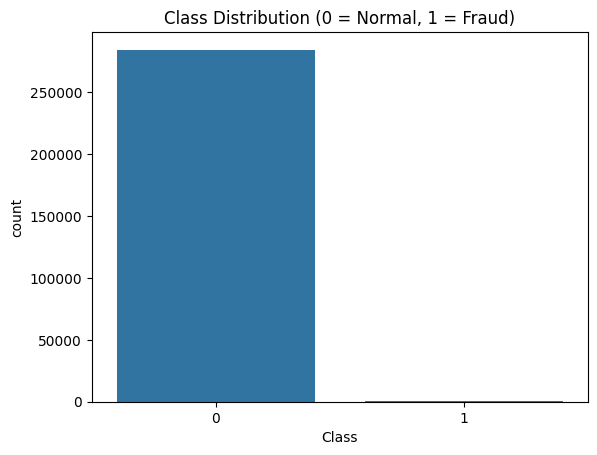

In [5]:
# Visualize class imbalance

sns.countplot(x="Class", data=df)
plt.title("Class Distribution (0 = Normal, 1 = Fraud)")
plt.show()

In [6]:
# Checking exact fraud percentage
fraud_percentage = (df["Class"].sum() / len(df)) * 100
print(f"Fraud Percentage: {fraud_percentage:.4f}%")

Fraud Percentage: 0.1727%


In [7]:
# STEP 2: Feature Preparation

from sklearn.preprocessing import StandardScaler

# Drop 'Time' column as it is not useful for prediction
df = df.drop(columns=["Time"])

# Scale 'Amount' column to normalize the values
scaler = StandardScaler()
df["Amount"] = scaler.fit_transform(df[["Amount"]])

# Define features (X) and target (y)
X = df.drop(columns=["Class"])
y = df["Class"]

# Display shapes to verify
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

# Insight:
# 'Time' column removed as it does not contribute to fraud detection
# 'Amount' scaled for better model performance
# V1–V28 are already PCA-transformed features, so no scaling needed
# Dataset is now ready for train-test split

Feature shape: (284807, 29)
Target shape: (284807,)


In [8]:
# STEP 3: Train-Test Split and Handling Imbalance

from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
# Stratify ensures same fraud ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

# Check class distribution after split
print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

# Insight:
# Stratified split is used because dataset is highly imbalanced
# It maintains the same proportion of fraud and normal cases in both sets

Training set: (227845, 29)
Testing set: (56962, 29)

Train class distribution:
Class
0    0.998271
1    0.001729
Name: proportion, dtype: float64

Test class distribution:
Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64


In [9]:
# STEP 4: Model Training with Imbalance Handling

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression with class_weight
# class_weight='balanced' helps handle imbalanced data
log_model = LogisticRegression(class_weight='balanced', max_iter=1000)

# Random Forest with class_weight
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)

# Train models
log_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

print("Models trained successfully")

# Insight:
# class_weight='balanced' adjusts weights inversely proportional to class frequency
# This helps the model pay more attention to fraud cases (minority class)

Models trained successfully


Logistic Regression Performance
Precision: 0.05878510777269758
Recall: 0.9183673469387755
ROC-AUC: 0.9714465520310545

Random Forest Performance
Precision: 0.961038961038961
Recall: 0.7551020408163265
ROC-AUC: 0.9580130501131234


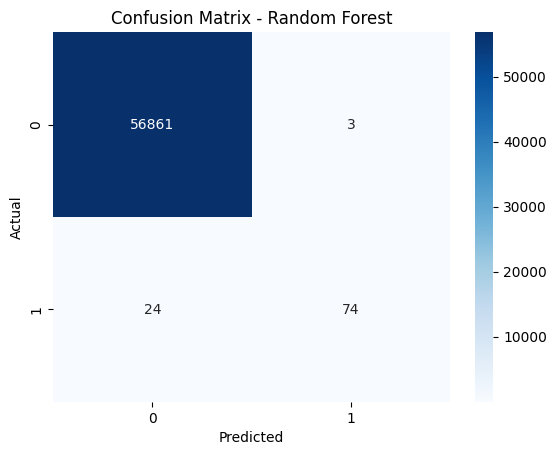


Classification Report - Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [10]:
# STEP 5: Model Evaluation

# Predictions
y_pred_log = log_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

# Probabilities for ROC-AUC
y_prob_log = log_model.predict_proba(X_test)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation Metrics

print("Logistic Regression Performance")
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

print("\nRandom Forest Performance")
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

# Confusion Matrix for Random Forest
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Detailed classification report
print("\nClassification Report - Random Forest")
print(classification_report(y_test, y_pred_rf))

# Insight:
# Accuracy is not reliable due to imbalance
# Precision → how many predicted frauds are correct
# Recall → how many actual frauds were detected
# ROC-AUC → overall model performance across thresholds

In [11]:
# STEP 6: Model Comparison

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

comparison

,Model,Precision,Recall,ROC-AUC
0,Logistic Regression,0.058785,0.918367,0.971447
1,Random Forest,0.961039,0.755102,0.958013


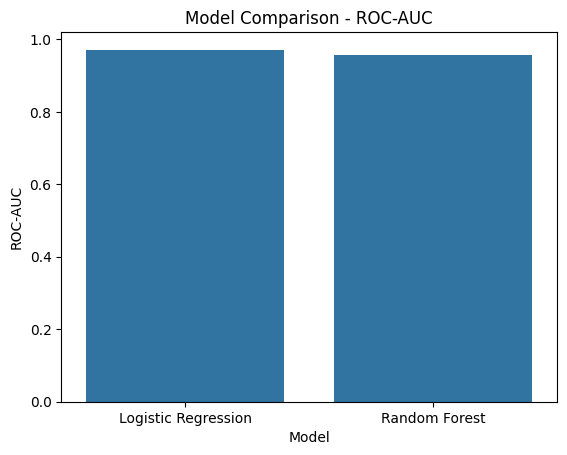

In [12]:
# STEP 7: Visual comparison of ROC-AUC

sns.barplot(x="Model", y="ROC-AUC", data=comparison)
plt.title("Model Comparison - ROC-AUC")
plt.show()

## Conclusion

In this project, a machine learning pipeline was developed to detect fraudulent credit card transactions using a highly imbalanced dataset.

The dataset was preprocessed by removing irrelevant features and scaling transaction amounts. Due to extreme class imbalance, stratified sampling and class_weight balancing techniques were applied.

Two models were evaluated:
- Logistic Regression (baseline model)
- Random Forest (ensemble model)

Model performance was assessed using Precision, Recall, and ROC-AUC instead of accuracy, as accuracy is not reliable for imbalanced datasets.

The Random Forest model demonstrated strong performance, particularly in identifying fraudulent transactions, while Logistic Regression provided a simpler baseline comparison.

This project highlights the importance of handling imbalanced data and selecting appropriate evaluation metrics for real-world fraud detection problems.